In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

train_path = "../data/raw/train.csv"
store_path = "../data/raw/store.csv"

train = pd.read_csv(train_path, low_memory=False)
store = pd.read_csv(store_path)

print("Train shape:", train.shape)
print("Store shape:", store.shape)


Train shape: (1017209, 9)
Store shape: (1115, 10)


In [4]:
print("TRAIN DATA")
display(train.head())

print("\nSTORE DATA")
display(store.head())

TRAIN DATA


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1



STORE DATA


,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [5]:
print("Train columns:")
print(train.columns.tolist())

print("\nStore columns:")
print(store.columns.tolist())

Train columns:
['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday']

Store columns:
['Store', 'StoreType', 'Assortment', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval']


In [6]:
print("TRAIN INFO")
train.info()

print("\nTRAIN MISSING VALUES")
display(train.isnull().sum())

print("\nSTORE MISSING VALUES")
display(store.isnull().sum())

TRAIN INFO
<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype
---  ------         --------------    -----
 0   Store          1017209 non-null  int64
 1   DayOfWeek      1017209 non-null  int64
 2   Date           1017209 non-null  str  
 3   Sales          1017209 non-null  int64
 4   Customers      1017209 non-null  int64
 5   Open           1017209 non-null  int64
 6   Promo          1017209 non-null  int64
 7   StateHoliday   1017209 non-null  str  
 8   SchoolHoliday  1017209 non-null  int64
dtypes: int64(7), str(2)
memory usage: 69.8 MB

TRAIN MISSING VALUES


Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64


STORE MISSING VALUES


Store                          0
StoreType                      0
Assortment                     0
CompetitionDistance            3
CompetitionOpenSinceMonth    354
CompetitionOpenSinceYear     354
Promo2                         0
Promo2SinceWeek              544
Promo2SinceYear              544
PromoInterval                544
dtype: int64

In [7]:
print("TRAIN STATISTICS")
display(train.describe())

print("\nSTORE STATISTICS")
display(store.describe())

TRAIN STATISTICS


,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday
count,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06
mean,5.584297e+02,3.998341e+00,5.773819e+03,6.331459e+02,8.301067e-01,3.815145e-01,1.786467e-01
std,3.219087e+02,1.997391e+00,3.849926e+03,4.644117e+02,3.755392e-01,4.857586e-01,3.830564e-01
min,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.800000e+02,2.000000e+00,3.727000e+03,4.050000e+02,1.000000e+00,0.000000e+00,0.000000e+00
50%,5.580000e+02,4.000000e+00,5.744000e+03,6.090000e+02,1.000000e+00,0.000000e+00,0.000000e+00
75%,8.380000e+02,6.000000e+00,7.856000e+03,8.370000e+02,1.000000e+00,1.000000e+00,0.000000e+00
max,1.115000e+03,7.000000e+00,4.155100e+04,7.388000e+03,1.000000e+00,1.000000e+00,1.000000e+00



STORE STATISTICS


,Store,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear
count,1115.00000,1112.000000,761.000000,761.000000,1115.000000,571.000000,571.000000
mean,558.00000,5404.901079,7.224704,2008.668857,0.512108,23.595447,2011.763573
std,322.01708,7663.174720,3.212348,6.195983,0.500078,14.141984,1.674935
min,1.00000,20.000000,1.000000,1900.000000,0.000000,1.000000,2009.000000
25%,279.50000,717.500000,4.000000,2006.000000,0.000000,13.000000,2011.000000
50%,558.00000,2325.000000,8.000000,2010.000000,1.000000,22.000000,2012.000000
75%,836.50000,6882.500000,10.000000,2013.000000,1.000000,37.000000,2013.000000
max,1115.00000,75860.000000,12.000000,2015.000000,1.000000,50.000000,2015.000000


In [8]:
train["Date"] = pd.to_datetime(train["Date"])

print("Minimum date:", train["Date"].min())
print("Maximum date:", train["Date"].max())

Minimum date: 2013-01-01 00:00:00
Maximum date: 2015-07-31 00:00:00


In [9]:
print("Unique stores:", train["Store"].nunique())
print("Total sales:", train["Sales"].sum())
print("Average sales per record:", train["Sales"].mean())
print("Total customers:", train["Customers"].sum())

print("\nPromotions:")
print(train["Promo"].value_counts())

print("\nStore types:")
print(store["StoreType"].value_counts())

Unique stores: 1115
Total sales: 5873180623
Average sales per record: 5773.818972305593
Total customers: 644041755

Promotions:
Promo
0    629129
1    388080
Name: count, dtype: int64

Store types:
StoreType
a    602
d    348
c    148
b     17
Name: count, dtype: int64


In [10]:
print("Duplicate train rows:", train.duplicated().sum())
print("Duplicate store rows:", store.duplicated().sum())

print("Negative sales:", (train["Sales"] < 0).sum())
print("Negative customers:", (train["Customers"] < 0).sum())

print(
    "Open stores with zero sales:",
    ((train["Open"] == 1) & (train["Sales"] == 0)).sum()
)

Duplicate train rows: 0
Duplicate store rows: 0
Negative sales: 0
Negative customers: 0
Open stores with zero sales: 54


In [12]:
closed_analysis = train.groupby("Open").agg(
    Records=("Store", "count"),
    Total_Sales=("Sales", "sum"),
    Avg_Sales=("Sales", "mean"),
    Avg_Customers=("Customers", "mean")
).reset_index()

closed_analysis

,Open,Records,Total_Sales,Avg_Sales,Avg_Customers
0,0,172817,0,0.000000,0.000000
1,1,844392,5873180623,6955.514291,762.728395


In [13]:
promo_analysis = train.groupby("Promo").agg(
    Total_Sales=("Sales", "sum"),
    Avg_Sales=("Sales", "mean"),
    Avg_Customers=("Customers", "mean"),
    Records=("Sales", "count")
).reset_index()

promo_analysis

,Promo,Total_Sales,Avg_Sales,Avg_Customers,Records
0,0,2771974337,4406.050805,517.823542,629129
1,1,3101206286,7991.152046,820.098815,388080


In [14]:
promo_analysis["Sales_per_Customer"] = (
    promo_analysis["Avg_Sales"] /
    promo_analysis["Avg_Customers"]
)

promo_analysis

,Promo,Total_Sales,Avg_Sales,Avg_Customers,Records,Sales_per_Customer
0,0,2771974337,4406.050805,517.823542,629129,8.508788
1,1,3101206286,7991.152046,820.098815,388080,9.744133


In [15]:
df = train.merge(
    store,
    on="Store",
    how="left",
    validate="many_to_one"
)

print("Merged shape:", df.shape)
print("Unique stores:", df["Store"].nunique())

Merged shape: (1017209, 18)
Unique stores: 1115


In [16]:
print("Rows before merge:", len(train))
print("Rows after merge:", len(df))

print(
    "Stores in train but missing after merge:",
    train.loc[~train["Store"].isin(store["Store"]), "Store"].nunique()
)

print("Missing StoreType:", df["StoreType"].isna().sum())

Rows before merge: 1017209
Rows after merge: 1017209
Stores in train but missing after merge: 0
Missing StoreType: 0


In [17]:

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["WeekOfYear"] = df["Date"].dt.isocalendar().week.astype(int)

df["IsWeekend"] = df["DayOfWeek"].isin([6, 7]).astype(int)

df["SalesPerCustomer"] = np.where(
    df["Customers"] > 0,
    df["Sales"] / df["Customers"],
    0
)

df["PromoCustomerInteraction"] = df["Promo"] * df["Customers"]

print(df.shape)

(1017209, 25)


In [18]:
df[
    [
        "Date",
        "Store",
        "Sales",
        "Customers",
        "Promo",
        "IsWeekend",
        "SalesPerCustomer"
    ]
].head(10)

,Date,Store,Sales,Customers,Promo,IsWeekend,SalesPerCustomer
0,2015-07-31,1,5263,555,1,0,9.482883
1,2015-07-31,2,6064,625,1,0,9.702400
2,2015-07-31,3,8314,821,1,0,10.126675
3,2015-07-31,4,13995,1498,1,0,9.342457
4,2015-07-31,5,4822,559,1,0,8.626118
5,2015-07-31,6,5651,589,1,0,9.594228
6,2015-07-31,7,15344,1414,1,0,10.851485
7,2015-07-31,8,8492,833,1,0,10.194478
8,2015-07-31,9,8565,687,1,0,12.467249
9,2015-07-31,10,7185,681,1,0,10.550661


In [19]:
store_performance = (
    df[df["Open"] == 1]
    .groupby("Store")
    .agg(
        Total_Sales=("Sales", "sum"),
        Avg_Daily_Sales=("Sales", "mean"),
        Total_Customers=("Customers", "sum"),
        Avg_Daily_Customers=("Customers", "mean"),
        Promo_Days=("Promo", "sum"),
        Operating_Days=("Open", "sum")
    )
    .reset_index()
)

store_performance["Sales_per_Customer"] = (
    store_performance["Total_Sales"] /
    store_performance["Total_Customers"]
)

store_performance.head()

,Store,Total_Sales,Avg_Daily_Sales,Total_Customers,Avg_Daily_Customers,Promo_Days,Operating_Days,Sales_per_Customer
0,1,3716854,4759.096031,440523,564.049936,350,781,8.437366
1,2,3883858,4953.900510,457855,583.998724,354,784,8.482725
2,3,5408261,6942.568678,584310,750.077022,350,779,9.255808
3,4,7556507,9638.401786,1036254,1321.752551,353,784,7.292138
4,5,3642818,4676.274711,418588,537.340180,351,779,8.702634


In [20]:
top_stores = store_performance.sort_values(
    "Total_Sales",
    ascending=False
).head(10)

top_stores

,Store,Total_Sales,Avg_Daily_Sales,Total_Customers,Avg_Daily_Customers,Promo_Days,Operating_Days,Sales_per_Customer
261,262,19516842,20718.515924,3204694,3402.010616,360,942,6.090080
816,817,17057867,21757.483418,2454370,3130.573980,353,784,6.949998
561,562,16927322,17969.556263,2924960,3105.053079,360,942,5.787198
1113,1114,16202585,20666.562500,2509542,3200.946429,353,784,6.456391
250,251,14896870,19123.068036,1908934,2450.492940,350,779,7.803764
512,513,14252406,18179.089286,1643527,2096.335459,353,784,8.671842
787,788,14082141,17961.914541,1346835,1717.901786,353,784,10.455728
732,733,14067158,14933.288747,3206058,3403.458599,360,942,4.387680
382,383,13489879,17294.716667,1720249,2205.447436,349,780,7.841818
755,756,12911782,16574.816431,1827980,2346.572529,350,779,7.063415


In [21]:
monthly_sales = (
    df[df["Open"] == 1]
    .groupby(["Year", "Month"])
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Customers=("Customers", "sum"),
        Avg_Daily_Sales=("Sales", "mean")
    )
    .reset_index()
)

monthly_sales

,Year,Month,Total_Sales,Total_Customers,Avg_Daily_Sales
0,2013,1,180132207,20380423,6239.641380
1,2013,2,171534275,19244468,6428.597796
2,2013,3,201180369,21969462,7212.834110
3,2013,4,183431432,20882365,6579.319656
4,2013,5,185411063,20723886,7076.217960
5,2013,6,180702351,20473046,6467.051428
6,2013,7,208843882,22872045,6923.154611
7,2013,8,198042727,22314232,6595.927627
8,2013,9,178053963,20350031,6363.388121
9,2013,10,187662330,21371258,6473.347016


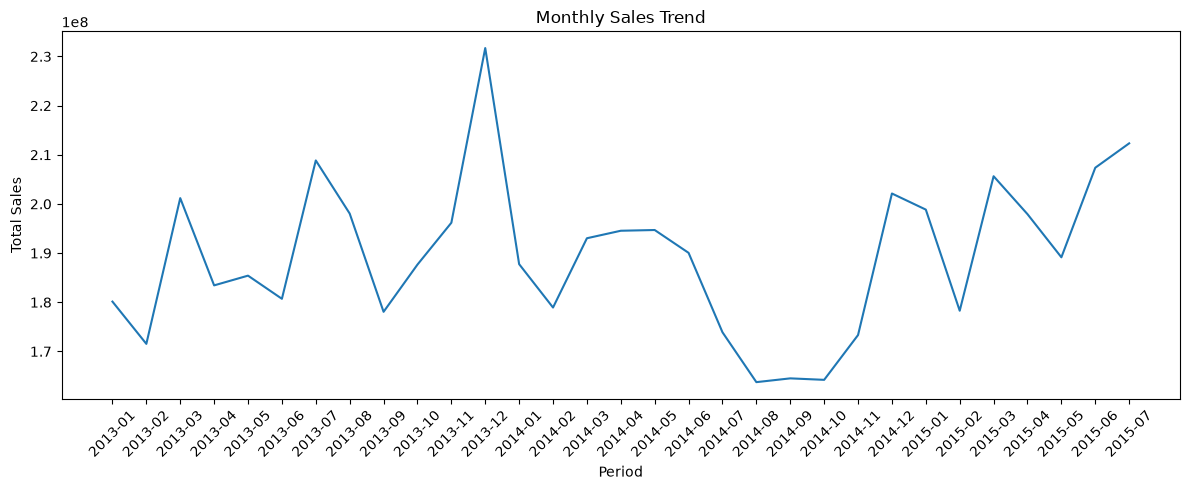

In [22]:
plt.figure(figsize=(12, 5))

monthly_sales["Period"] = (
    monthly_sales["Year"].astype(str)
    + "-"
    + monthly_sales["Month"].astype(str).str.zfill(2)
)

plt.plot(
    monthly_sales["Period"],
    monthly_sales["Total_Sales"]
)

plt.xticks(rotation=45)
plt.title("Monthly Sales Trend")
plt.xlabel("Period")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()

In [23]:
store_type_analysis = (
    df[df["Open"] == 1]
    .groupby("StoreType")
    .agg(
        Stores=("Store", "nunique"),
        Total_Sales=("Sales", "sum"),
        Avg_Daily_Sales=("Sales", "mean"),
        Total_Customers=("Customers", "sum"),
        Avg_Daily_Customers=("Customers", "mean")
    )
    .reset_index()
)

store_type_analysis["Sales_per_Customer"] = (
    store_type_analysis["Total_Sales"] /
    store_type_analysis["Total_Customers"]
)

store_type_analysis

,StoreType,Stores,Total_Sales,Avg_Daily_Sales,Total_Customers,Avg_Daily_Customers,Sales_per_Customer
0,a,602,3165334859,6925.167661,363541434,795.361469,8.706944
1,b,17,159231395,10231.407505,31465621,2021.822335,5.060488
2,c,148,783221426,6932.512755,92129705,815.465887,8.501291
3,d,348,1765392943,6822.141881,156904995,606.339876,11.251350


In [24]:
df = df.sort_values(
    ["Store", "Date"]
).reset_index(drop=True)

print(df[["Store", "Date", "Sales"]].head(10))

   Store       Date  Sales
0      1 2013-01-01      0
1      1 2013-01-02   5530
2      1 2013-01-03   4327
3      1 2013-01-04   4486
4      1 2013-01-05   4997
5      1 2013-01-06      0
6      1 2013-01-07   7176
7      1 2013-01-08   5580
8      1 2013-01-09   5471
9      1 2013-01-10   4892


In [25]:
df["Sales_Lag_1"] = (
    df.groupby("Store")["Sales"]
      .shift(1)
)

df["Sales_Lag_7"] = (
    df.groupby("Store")["Sales"]
      .shift(7)
)

df["Customers_Lag_1"] = (
    df.groupby("Store")["Customers"]
      .shift(1)
)

In [26]:
df["Sales_Rolling_7"] = (
    df.groupby("Store")["Sales"]
      .transform(
          lambda x: x.shift(1).rolling(7).mean()
      )
)

df["Sales_Rolling_30"] = (
    df.groupby("Store")["Sales"]
      .transform(
          lambda x: x.shift(1).rolling(30).mean()
      )
)

In [27]:
df["Sales_Rolling_7_Std"] = (
    df.groupby("Store")["Sales"]
      .transform(
          lambda x: x.shift(1).rolling(7).std()
      )
)

In [28]:
df[
    [
        "Store",
        "Date",
        "Sales",
        "Sales_Lag_1",
        "Sales_Lag_7",
        "Sales_Rolling_7",
        "Sales_Rolling_30",
        "Sales_Rolling_7_Std"
    ]
].head(20)

,Store,Date,Sales,Sales_Lag_1,Sales_Lag_7,Sales_Rolling_7,Sales_Rolling_30,Sales_Rolling_7_Std
0,1,2013-01-01,0,NaN,NaN,NaN,NaN,NaN
1,1,2013-01-02,5530,0.0,NaN,NaN,NaN,NaN
2,1,2013-01-03,4327,5530.0,NaN,NaN,NaN,NaN
3,1,2013-01-04,4486,4327.0,NaN,NaN,NaN,NaN
4,1,2013-01-05,4997,4486.0,NaN,NaN,NaN,NaN
5,1,2013-01-06,0,4997.0,NaN,NaN,NaN,NaN
6,1,2013-01-07,7176,0.0,NaN,NaN,NaN,NaN
7,1,2013-01-08,5580,7176.0,0.0,3788.000000,NaN,2752.283961
8,1,2013-01-09,5471,5580.0,5530.0,4585.142857,NaN,2231.018633
9,1,2013-01-10,4892,5471.0,4327.0,4576.714286,NaN,2226.961885


In [29]:
print("Total rows:", len(df))

print("Missing Lag 1:", df["Sales_Lag_1"].isna().sum())
print("Missing Lag 7:", df["Sales_Lag_7"].isna().sum())
print("Missing Rolling 7:", df["Sales_Rolling_7"].isna().sum())
print("Missing Rolling 30:", df["Sales_Rolling_30"].isna().sum())

Total rows: 1017209
Missing Lag 1: 1115
Missing Lag 7: 7805
Missing Rolling 7: 7805
Missing Rolling 30: 33450


In [36]:
daily = df[
    [
        "Store",
        "Date",
        "Sales",
        "Customers",
        "Open",
        "Promo",
        "SchoolHoliday",
        "StateHoliday",
        "StoreType",
        "Assortment",
        "CompetitionDistance"
    ]
].copy()

daily = daily.sort_values(
    ["Store", "Date"]
).reset_index(drop=True)

print(daily.shape)
print(daily.columns.tolist())

(1017209, 11)
['Store', 'Date', 'Sales', 'Customers', 'Open', 'Promo', 'SchoolHoliday', 'StateHoliday', 'StoreType', 'Assortment', 'CompetitionDistance']


In [31]:
lag_source = daily[["Store", "Date", "Sales"]].copy()

for days in [1, 7, 14, 30]:
    lag_source[f"Sales_Lag_{days}"] = lag_source["Date"] + pd.Timedelta(days=days)

daily = daily.merge(
    lag_source[
        ["Store", "Date", "Sales_Lag_1", "Sales_Lag_7",
         "Sales_Lag_14", "Sales_Lag_30"]
    ],
    on=["Store", "Date"],
    how="left"
)

In [37]:
for days in [1, 7, 14, 30]:

    lag_df = daily[["Store", "Date", "Sales"]].copy()

    # Move the historical date forward so it matches the future row
    lag_df["Date"] = lag_df["Date"] + pd.Timedelta(days=days)

    lag_df = lag_df.rename(
        columns={"Sales": f"Sales_Lag_{days}"}
    )

    daily = daily.merge(
        lag_df,
        on=["Store", "Date"],
        how="left"
    )

print(
    daily[
        [
            "Sales_Lag_1",
            "Sales_Lag_7",
            "Sales_Lag_14",
            "Sales_Lag_30"
        ]
    ].head()
)

   Sales_Lag_1  Sales_Lag_7  Sales_Lag_14  Sales_Lag_30
0          NaN          NaN           NaN           NaN
1          0.0          NaN           NaN           NaN
2       5530.0          NaN           NaN           NaN
3       4327.0          NaN           NaN           NaN
4       4486.0          NaN           NaN           NaN


In [38]:
daily[
    [
        "Store",
        "Date",
        "Sales",
        "Sales_Lag_1",
        "Sales_Lag_7",
        "Sales_Lag_14",
        "Sales_Lag_30"
    ]
].head(35)

,Store,Date,Sales,Sales_Lag_1,Sales_Lag_7,Sales_Lag_14,Sales_Lag_30
0,1,2013-01-01,0,NaN,NaN,NaN,NaN
1,1,2013-01-02,5530,0.0,NaN,NaN,NaN
2,1,2013-01-03,4327,5530.0,NaN,NaN,NaN
3,1,2013-01-04,4486,4327.0,NaN,NaN,NaN
4,1,2013-01-05,4997,4486.0,NaN,NaN,NaN
5,1,2013-01-06,0,4997.0,NaN,NaN,NaN
6,1,2013-01-07,7176,0.0,NaN,NaN,NaN
7,1,2013-01-08,5580,7176.0,0.0,NaN,NaN
8,1,2013-01-09,5471,5580.0,5530.0,NaN,NaN
9,1,2013-01-10,4892,5471.0,4327.0,NaN,NaN


In [39]:
daily = daily.sort_values(["Store", "Date"]).reset_index(drop=True)

daily["Sales_Rolling_7"] = (
    daily.groupby("Store")["Sales"]
    .transform(
        lambda x: x.shift(1).rolling(7).mean()
    )
)

daily["Sales_Rolling_14"] = (
    daily.groupby("Store")["Sales"]
    .transform(
        lambda x: x.shift(1).rolling(14).mean()
    )
)

daily["Sales_Rolling_30"] = (
    daily.groupby("Store")["Sales"]
    .transform(
        lambda x: x.shift(1).rolling(30).mean()
    )
)

daily["Sales_Rolling_7_Std"] = (
    daily.groupby("Store")["Sales"]
    .transform(
        lambda x: x.shift(1).rolling(7).std()
    )
)

In [40]:
daily[
    [
        "Store",
        "Date",
        "Sales",
        "Sales_Lag_1",
        "Sales_Lag_7",
        "Sales_Rolling_7",
        "Sales_Rolling_14",
        "Sales_Rolling_30",
        "Sales_Rolling_7_Std"
    ]
].head(35)

,Store,Date,Sales,Sales_Lag_1,Sales_Lag_7,Sales_Rolling_7,Sales_Rolling_14,Sales_Rolling_30,Sales_Rolling_7_Std
0,1,2013-01-01,0,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2013-01-02,5530,0.0,NaN,NaN,NaN,NaN,NaN
2,1,2013-01-03,4327,5530.0,NaN,NaN,NaN,NaN,NaN
3,1,2013-01-04,4486,4327.0,NaN,NaN,NaN,NaN,NaN
4,1,2013-01-05,4997,4486.0,NaN,NaN,NaN,NaN,NaN
5,1,2013-01-06,0,4997.0,NaN,NaN,NaN,NaN,NaN
6,1,2013-01-07,7176,0.0,NaN,NaN,NaN,NaN,NaN
7,1,2013-01-08,5580,7176.0,0.0,3788.000000,NaN,NaN,2752.283961
8,1,2013-01-09,5471,5580.0,5530.0,4585.142857,NaN,NaN,2231.018633
9,1,2013-01-10,4892,5471.0,4327.0,4576.714286,NaN,NaN,2226.961885


In [41]:
daily["Year"] = daily["Date"].dt.year
daily["Month"] = daily["Date"].dt.month
daily["Day"] = daily["Date"].dt.day
daily["DayOfWeek"] = daily["Date"].dt.dayofweek + 1
daily["WeekOfYear"] = daily["Date"].dt.isocalendar().week.astype(int)

daily["IsWeekend"] = daily["DayOfWeek"].isin([6, 7]).astype(int)

In [42]:
daily[
    [
        "Date",
        "Year",
        "Month",
        "Day",
        "DayOfWeek",
        "WeekOfYear",
        "IsWeekend"
    ]
].head(10)

,Date,Year,Month,Day,DayOfWeek,WeekOfYear,IsWeekend
0,2013-01-01,2013,1,1,2,1,0
1,2013-01-02,2013,1,2,3,1,0
2,2013-01-03,2013,1,3,4,1,0
3,2013-01-04,2013,1,4,5,1,0
4,2013-01-05,2013,1,5,6,1,1
5,2013-01-06,2013,1,6,7,1,1
6,2013-01-07,2013,1,7,1,2,0
7,2013-01-08,2013,1,8,2,2,0
8,2013-01-09,2013,1,9,3,2,0
9,2013-01-10,2013,1,10,4,2,0


In [43]:
model_features = [
    "Store",
    "DayOfWeek",
    "Month",
    "Year",
    "WeekOfYear",
    "IsWeekend",
    "Promo",
    "SchoolHoliday",
    "StateHoliday",
    "StoreType",
    "Assortment",
    "CompetitionDistance",
    "Sales_Lag_1",
    "Sales_Lag_7",
    "Sales_Lag_14",
    "Sales_Lag_30",
    "Sales_Rolling_7",
    "Sales_Rolling_14",
    "Sales_Rolling_30",
    "Sales_Rolling_7_Std"
]

target = "Sales"

model_df = daily[model_features + [target]].copy()

print("Original rows:", len(model_df))
print("Missing rows:", model_df.isna().any(axis=1).sum())

Original rows: 1017209
Missing rows: 41372


In [44]:
model_df = model_df.dropna().reset_index(drop=True)

print("Rows after removing insufficient history:", len(model_df))
print("Remaining missing values:", model_df.isna().sum().sum())

Rows after removing insufficient history: 975837
Remaining missing values: 0


In [49]:
print("Earliest date:", daily["Date"].min())
print("Latest date:", daily["Date"].max())

print("Model shape:", model_df.shape)

print(model_df.head())

Earliest date: 2013-01-01 00:00:00
Latest date: 2015-07-31 00:00:00
Model shape: (975837, 21)
   Store  DayOfWeek  Month  Year  WeekOfYear  IsWeekend  Promo  SchoolHoliday  \
0      1          4      1  2013           5          0      0              0   
1      1          5      2  2013           5          0      0              0   
2      1          6      2  2013           5          1      0              0   
3      1          7      2  2013           5          1      0              0   
4      1          1      2  2013           6          0      1              0   

  StateHoliday StoreType Assortment  CompetitionDistance  Sales_Lag_1  \
0            0         c          a               1270.0       4601.0   
1            0         c          a               1270.0       4709.0   
2            0         c          a               1270.0       5633.0   
3            0         c          a               1270.0       5970.0   
4            0         c          a               1270